<a href="https://colab.research.google.com/github/2d-game-dev/ComputerVisionProject/blob/main/finalCVversionIguess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ce2bdqFeT7e9MGJbnEPa")
project = rf.workspace("my-workspace-y2ace").project("cctv-naxyo-drk6y")
dataset = project.version(1).download("yolov5")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cctv-1 in yolov5pytorch:: 100%|██████████| 7479/7479 [00:09<00:00, 755.95it/s] 


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

In [3]:
class GridDataset(Dataset):
    def __init__(self, images_path, labels_path, grid_size=7, max_images=1000):
        self.images = []
        self.labels = []
        self.grid_size = grid_size

        img_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.png'))]

        for img_file in img_files[:max_images]:
            label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
            label_path = os.path.join(labels_path, label_file)

            grid = np.zeros((grid_size, grid_size, 5))  # [conf, x, y, w, h]

            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) == 5:
                            _, x, y, w, h = map(float, parts)

                            gx = int(x * grid_size)
                            gy = int(y * grid_size)

                            if gx < grid_size and gy < grid_size:
                                grid[gy, gx] = [1, x, y, w, h]

            self.images.append(os.path.join(images_path, img_file))
            self.labels.append(grid)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        img = img.resize((224, 224))
        img = np.array(img) / 255.0
        img = torch.FloatTensor(img).permute(2, 0, 1)

        label = torch.FloatTensor(self.labels[idx])
        return img, label

In [4]:
class GridDetectionModel(nn.Module):
    def __init__(self, grid_size=7):
        super().__init__()
        self.grid_size = grid_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Linear(128 * 14 * 14, 1024)
        self.output = nn.Linear(1024, grid_size * grid_size * 5)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc(x))
        x = self.output(x)
        x = x.view(-1, self.grid_size, self.grid_size, 5)
        return x

In [5]:
def detection_loss(pred, target):
    obj_mask = target[..., 0] > 0

    loss_conf = ((pred[..., 0] - target[..., 0]) ** 2).mean()

    if obj_mask.sum() > 0:
        loss_bbox = ((pred[obj_mask][..., 1:] - target[obj_mask][..., 1:]) ** 2).mean()
    else:
        loss_bbox = 0

    return loss_conf + loss_bbox

In [6]:
dataset_path = "/content/cctv-1"

train_dataset = GridDataset(f"{dataset_path}/train/images", f"{dataset_path}/train/labels")
val_dataset = GridDataset(f"{dataset_path}/valid/images", f"{dataset_path}/valid/labels")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GridDetectionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, targets in tqdm(train_loader):
        images, targets = images.to(device), targets.to(device)

        preds = model(images)
        loss = detection_loss(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

100%|██████████| 63/63 [01:43<00:00,  1.65s/it]


Epoch 1: Loss = 5.1257


100%|██████████| 63/63 [01:38<00:00,  1.57s/it]


Epoch 2: Loss = 4.3530


100%|██████████| 63/63 [01:39<00:00,  1.59s/it]


...

Epoch 8: Loss = 2.6752


100%|██████████| 63/63 [01:41<00:00,  1.61s/it]


Epoch 9: Loss = 2.4155


100%|██████████| 63/63 [01:42<00:00,  1.63s/it]

Epoch 10: Loss = 2.2764


In [8]:
def detect_intrusion(model, image_path, restricted_zone=[0.3,0.4,0.7,0.6], threshold=0.5):
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224,224))
    img_tensor = torch.FloatTensor(np.array(img_resized)/255.0).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)[0].cpu().numpy()

    intrusion = False
    boxes = []

    for i in range(pred.shape[0]):
        for j in range(pred.shape[1]):
            conf = pred[i,j,0]
            if conf > threshold:
                x,y,w,h = pred[i,j,1:]
                boxes.append((x,y,w,h))

                if restricted_zone[0] < x < restricted_zone[2] and restricted_zone[1] < y < restricted_zone[3]:
                    intrusion = True

    # Visualization
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    h_img, w_img = img.size[1], img.size[0]

    # Draw restricted zone
    rz = patches.Rectangle((restricted_zone[0]*w_img, restricted_zone[1]*h_img),
                           (restricted_zone[2]-restricted_zone[0])*w_img,
                           (restricted_zone[3]-restricted_zone[1])*h_img,
                           edgecolor='red', facecolor='red', alpha=0.3)
    ax.add_patch(rz)

    # Draw boxes
    for (x,y,w,h) in boxes:
        rect = patches.Rectangle(((x-w/2)*w_img,(y-h/2)*h_img),
                                 w*w_img,h*h_img,
                                 edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)

    if intrusion:
        plt.title("🚨 INTRUSION DETECTED", color="red")
    else:
        plt.title("✅ SAFE")

    plt.axis('off')
    plt.show()

    return intrusion

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.


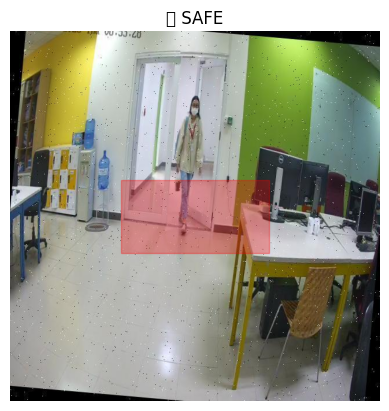

False

In [9]:
test_image = val_dataset.images[0]
detect_intrusion(model, test_image)

Frame 1


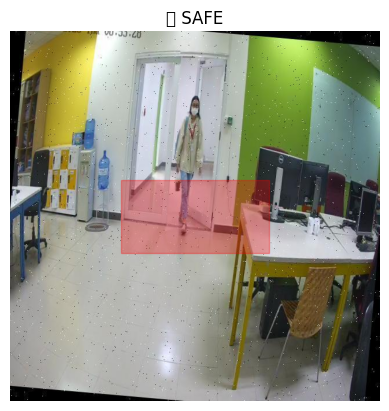

Frame 2


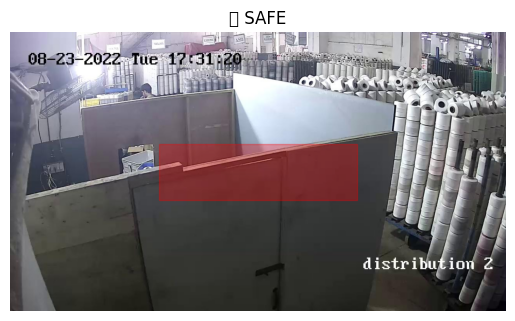

Frame 3


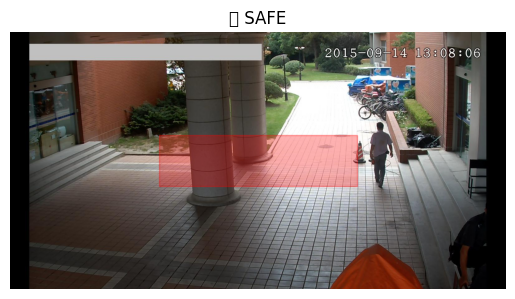

Frame 4


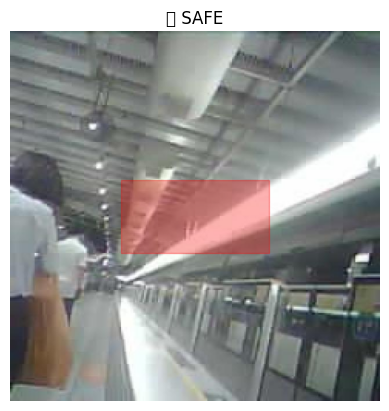

Frame 5


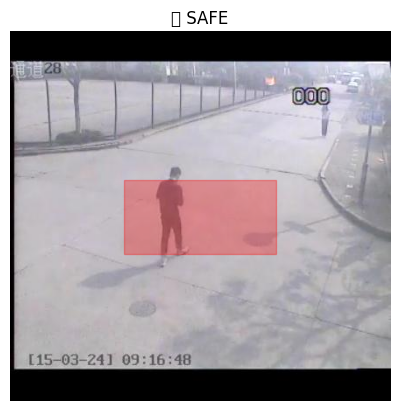

Frame 6


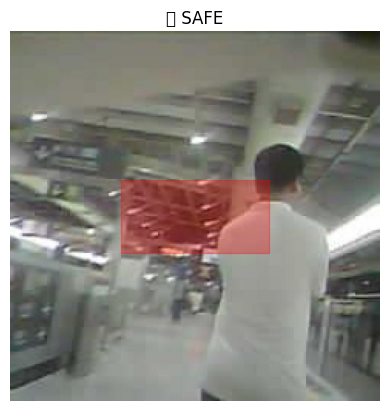

Frame 7


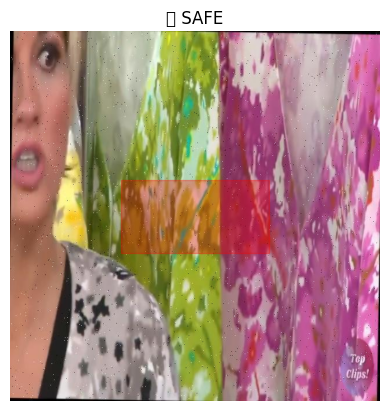

Frame 8


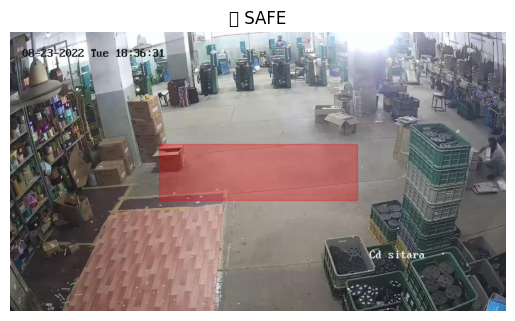

Frame 9


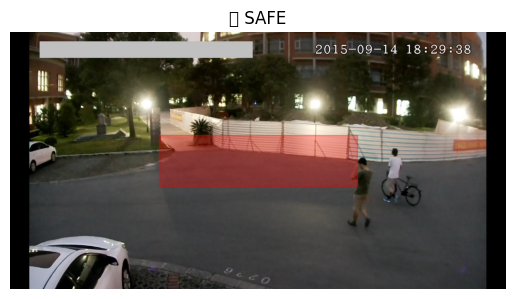

Frame 10


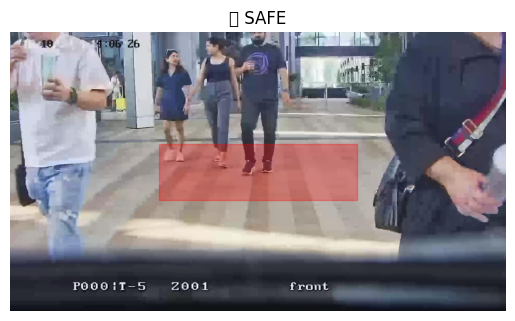

In [10]:
def simulate_cctv(model, folder, delay=1):
    images = os.listdir(folder)

    for i, img in enumerate(images[:10]):
        print(f"Frame {i+1}")
        detect_intrusion(model, os.path.join(folder, img))
        plt.pause(delay)

simulate_cctv(model, os.path.dirname(val_dataset.images[0]))